# ECG Classification â€“ Eksperimen Skema Preprocessing

Notebook ini melatih model klasifikasi ECG dengan **3 skema preprocessing** dan **2 task klasifikasi**, sehingga total terdapat **6 kombinasi eksperimen**.

| Skema | Input | Task |
|---|---|---|
| Skema 1 | Gambar clean (1 gambar/sampel) | 2-class & 4-class |
| Skema 2 | 12 short lead + 1 long lead | 2-class & 4-class |
| Skema 3 | 6 lead tungkai + 6 lead precordial + long lead | 2-class & 4-class |

Semua eksperimen di-tracking menggunakan **MLflow via DagsHub**.

## 1. Import & Konfigurasi

In [1]:
import torch
from utils.config import Config
from utils.modeling import (
    init_dagshub,
    CLASS_NAMES_2, CLASS_NAMES_4,
    SCHEME_NAMES,
)

c:\Users\abiyamf\Documents\Code Program\TelUxMMU-Research-CardiacData\.venv\Lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## GPU Check

In [2]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU tidak tersedia, menggunakan CPU")

GPU: NVIDIA GeForce RTX 5070 Ti
Memory: 17.1 GB


In [3]:
# â”€â”€ Hyperparameter â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
NUM_EPOCHS    = 3
BATCH_SIZE    = 16
LEARNING_RATE = 1e-4
IMAGE_SIZE    = 224
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
OUTPUT_DIR    = "outputs/experiments"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Inisialisasi DagsHub & MLflow

In [4]:
init_dagshub(
    repo_owner=Config.dagshub_config["repo_owner"],
    repo_name=Config.dagshub_config["repo_name"],
)

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/TelUxMMU-Research"

Repository abiyamf/TelUxMMU-Research initialized!

DagsHub initialized: https://dagshub.com/abiyamf/TelUxMMU-Research


In [5]:
from utils.modeling import (
    _get_image_files_scheme1,
    ECGDatasetScheme1,
    build_dataloaders,
    build_model,
    train_model,
    evaluate_and_log,
)

records_s1 = _get_image_files_scheme1(Config.data_root)

dataset_s1_4c = ECGDatasetScheme1(records_s1, task="4class", image_size=IMAGE_SIZE)
train_s1_4c, val_s1_4c, test_s1_4c = build_dataloaders(
    dataset_s1_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_s1_4c, history_s1_4c, run_output_dir = train_model(
    model_s1_4c, train_s1_4c, val_s1_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_4class",
    scheme="scheme1", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme1_4class] Epoch 1/3 | Train Loss: 0.5246 Acc: 0.8071 | Val Loss: 0.3746 Acc: 0.8286
[scheme1_4class] Epoch 2/3 | Train Loss: 0.1011 Acc: 0.9769 | Val Loss: 0.0759 Acc: 0.9643


2026/04/19 15:21:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_4class] Epoch 3/3 | Train Loss: 0.0387 Acc: 0.9907 | Val Loss: 0.0768 Acc: 0.9786


2026/04/19 15:21:05 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\abiyamf\AppData\Local\Temp\tmp05r_9r3p\model\data, flavor: pytorch), fall back to return ['torch==2.11.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.
2026/04/19 15:21:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_4class\best_model.pth
Training history saved to: outputs/experiments\scheme1_4class\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_4class\confusion_matrix_val.png


In [6]:
result_s1_4c = evaluate_and_log(
    model_s1_4c, test_s1_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme1", task="4class",
    run_name="scheme1_4class", output_dir=run_output_dir)


=== Test Results | scheme1 | 4class ===
Accuracy : 0.9500
Macro F1 : 0.9457
              precision    recall  f1-score   support

      Normal       0.91      1.00      0.96        43
    Abnormal       0.97      0.89      0.93        35
          MI       1.00      1.00      1.00        36
  History MI       0.92      0.88      0.90        26

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.95       140
weighted avg       0.95      0.95      0.95       140

Test confusion matrix saved to: outputs/experiments\scheme1_4class\confusion_matrix_test.png


In [7]:
from utils.modeling import (
    _get_image_files_scheme1,
    ECGDatasetScheme1,
    build_dataloaders,
    build_model,
    train_model,
    evaluate_and_log,
)

records_s1 = _get_image_files_scheme1(Config.data_root)

dataset_s1_4c = ECGDatasetScheme1(records_s1, task="4class", image_size=IMAGE_SIZE)
train_s1_4c, val_s1_4c, test_s1_4c = build_dataloaders(
    dataset_s1_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_s1_4c, history_s1_4c, run_output_dir = train_model(
    model_s1_4c, train_s1_4c, val_s1_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_4class",
    output_dir=OUTPUT_DIR,
    scheme="scheme1", task="4class"
)

[scheme1_4class] Epoch 1/3 | Train Loss: 0.5041 Acc: 0.8009 | Val Loss: 0.3327 Acc: 0.9071
[scheme1_4class] Epoch 2/3 | Train Loss: 0.0850 Acc: 0.9769 | Val Loss: 0.0860 Acc: 0.9857


2026/04/19 15:24:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_4class] Epoch 3/3 | Train Loss: 0.0551 Acc: 0.9877 | Val Loss: 0.0987 Acc: 0.9643


2026/04/19 15:24:20 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:24:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_4class\best_model.pth
Training history saved to: outputs/experiments\scheme1_4class\training_history.png


In [8]:
dataset_s1_2c = ECGDatasetScheme1(records_s1, task="2class", image_size=IMAGE_SIZE)
train_s1_2c, val_s1_2c, test_s1_2c = build_dataloaders(
    dataset_s1_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_s1_2c, history_s1_2c, run_output_dir = train_model(
    model_s1_2c, train_s1_2c, val_s1_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_2class",
    scheme="scheme1", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme1_2class] Epoch 1/3 | Train Loss: 0.2353 Acc: 0.9105 | Val Loss: 0.1147 Acc: 0.9714
[scheme1_2class] Epoch 2/3 | Train Loss: 0.0721 Acc: 0.9784 | Val Loss: 0.0416 Acc: 0.9857


2026/04/19 15:27:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_2class] Epoch 3/3 | Train Loss: 0.0141 Acc: 0.9969 | Val Loss: 0.0313 Acc: 0.9857


2026/04/19 15:27:13 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:27:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_2class\best_model.pth
Training history saved to: outputs/experiments\scheme1_2class\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_2class\confusion_matrix_val.png


In [9]:
result_s1_2c = evaluate_and_log(
    model_s1_2c, test_s1_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme1", task="2class",
    run_name="scheme1_2class", output_dir=run_output_dir)


=== Test Results | scheme1 | 2class ===
Accuracy : 0.9857
Macro F1 : 0.9834
              precision    recall  f1-score   support

       Sehat       0.96      1.00      0.98        43
       Sakit       1.00      0.98      0.99        97

    accuracy                           0.99       140
   macro avg       0.98      0.99      0.98       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme1_2class\confusion_matrix_test.png


In [10]:
dataset_s1_2c = ECGDatasetScheme1(records_s1, task="2class", image_size=IMAGE_SIZE)
train_s1_2c, val_s1_2c, test_s1_2c = build_dataloaders(
    dataset_s1_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_s1_2c, history_s1_2c, run_output_dir = train_model(
    model_s1_2c, train_s1_2c, val_s1_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_2class",
    output_dir=OUTPUT_DIR,
    scheme="scheme1", task="2class"
)

[scheme1_2class] Epoch 1/3 | Train Loss: 0.3278 Acc: 0.8380 | Val Loss: 0.2098 Acc: 0.9357
[scheme1_2class] Epoch 2/3 | Train Loss: 0.0552 Acc: 0.9830 | Val Loss: 0.0928 Acc: 0.9571


2026/04/19 15:30:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_2class] Epoch 3/3 | Train Loss: 0.0626 Acc: 0.9784 | Val Loss: 0.1092 Acc: 0.9714


2026/04/19 15:30:10 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:30:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_2class\best_model.pth
Training history saved to: outputs/experiments\scheme1_2class\training_history.png


In [11]:
result_s1_2c = evaluate_and_log(
    model_s1_2c, test_s1_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme1", task="2class"
)


=== Test Results | scheme1 | 2class ===
Accuracy : 0.9786
Macro F1 : 0.9753
              precision    recall  f1-score   support

       Sehat       0.93      1.00      0.97        43
       Sakit       1.00      0.97      0.98        97

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



In [12]:
from utils.modeling import _get_image_files_scheme2, ECGDatasetScheme2

records_s2 = _get_image_files_scheme2(Config.data_root)

dataset_s2_4c = ECGDatasetScheme2(records_s2, task="4class", image_size=IMAGE_SIZE)
train_s2_4c, val_s2_4c, test_s2_4c = build_dataloaders(
    dataset_s2_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# 13 leads x 3 channels = 39 input channels
model_s2_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s2_4c, history_s2_4c, run_output_dir = train_model(
    model_s2_4c, train_s2_4c, val_s2_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_4class",
    scheme="scheme2", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme2_4class] Epoch 1/3 | Train Loss: 0.5738 Acc: 0.7948 | Val Loss: 0.3879 Acc: 0.8286
[scheme2_4class] Epoch 2/3 | Train Loss: 0.1016 Acc: 0.9784 | Val Loss: 0.2547 Acc: 0.9143


2026/04/19 15:34:59 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_4class] Epoch 3/3 | Train Loss: 0.0563 Acc: 0.9861 | Val Loss: 0.2272 Acc: 0.9214


2026/04/19 15:35:04 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:35:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_4class\best_model.pth
Training history saved to: outputs/experiments\scheme2_4class\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_4class\confusion_matrix_val.png


In [13]:
result_s2_4c = evaluate_and_log(
    model_s2_4c, test_s2_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme2", task="4class",
    run_name="scheme2_4class", output_dir=run_output_dir)


=== Test Results | scheme2 | 4class ===
Accuracy : 0.8929
Macro F1 : 0.8958
              precision    recall  f1-score   support

      Normal       0.95      0.81      0.88        43
    Abnormal       0.73      0.91      0.81        35
          MI       1.00      1.00      1.00        36
  History MI       0.96      0.85      0.90        26

    accuracy                           0.89       140
   macro avg       0.91      0.89      0.90       140
weighted avg       0.91      0.89      0.90       140

Test confusion matrix saved to: outputs/experiments\scheme2_4class\confusion_matrix_test.png


In [14]:
from utils.modeling import _get_image_files_scheme2, ECGDatasetScheme2

records_s2 = _get_image_files_scheme2(Config.data_root)

dataset_s2_4c = ECGDatasetScheme2(records_s2, task="4class", image_size=IMAGE_SIZE)
train_s2_4c, val_s2_4c, test_s2_4c = build_dataloaders(
    dataset_s2_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# 13 leads x 3 channels = 39 input channels
model_s2_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s2_4c, history_s2_4c, run_output_dir = train_model(
    model_s2_4c, train_s2_4c, val_s2_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_4class",
    output_dir=OUTPUT_DIR,
    scheme="scheme2", task="4class"
)

[scheme2_4class] Epoch 1/3 | Train Loss: 0.5812 Acc: 0.7948 | Val Loss: 0.6941 Acc: 0.7143
[scheme2_4class] Epoch 2/3 | Train Loss: 0.1177 Acc: 0.9738 | Val Loss: 0.2080 Acc: 0.9214


2026/04/19 15:39:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_4class] Epoch 3/3 | Train Loss: 0.0391 Acc: 0.9923 | Val Loss: 0.3716 Acc: 0.8643


2026/04/19 15:39:09 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:39:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_4class\best_model.pth
Training history saved to: outputs/experiments\scheme2_4class\training_history.png


In [15]:
dataset_s2_2c = ECGDatasetScheme2(records_s2, task="2class", image_size=IMAGE_SIZE)
train_s2_2c, val_s2_2c, test_s2_2c = build_dataloaders(
    dataset_s2_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s2_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s2_2c, history_s2_2c, run_output_dir = train_model(
    model_s2_2c, train_s2_2c, val_s2_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_2class",
    scheme="scheme2", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme2_2class] Epoch 1/3 | Train Loss: 0.2779 Acc: 0.8719 | Val Loss: 0.1733 Acc: 0.9714
[scheme2_2class] Epoch 2/3 | Train Loss: 0.0594 Acc: 0.9877 | Val Loss: 0.1888 Acc: 0.9500


2026/04/19 15:42:53 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_2class] Epoch 3/3 | Train Loss: 0.0979 Acc: 0.9630 | Val Loss: 0.1320 Acc: 0.9643


2026/04/19 15:42:58 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:42:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_2class\best_model.pth
Training history saved to: outputs/experiments\scheme2_2class\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_2class\confusion_matrix_val.png


In [16]:
result_s2_2c = evaluate_and_log(
    model_s2_2c, test_s2_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme2", task="2class",
    run_name="scheme2_2class", output_dir=run_output_dir)


=== Test Results | scheme2 | 2class ===
Accuracy : 0.9929
Macro F1 : 0.9916
              precision    recall  f1-score   support

       Sehat       1.00      0.98      0.99        43
       Sakit       0.99      1.00      0.99        97

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme2_2class\confusion_matrix_test.png


In [17]:
dataset_s2_2c = ECGDatasetScheme2(records_s2, task="2class", image_size=IMAGE_SIZE)
train_s2_2c, val_s2_2c, test_s2_2c = build_dataloaders(
    dataset_s2_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s2_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s2_2c, history_s2_2c, run_output_dir = train_model(
    model_s2_2c, train_s2_2c, val_s2_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_2class",
    output_dir=OUTPUT_DIR,
    scheme="scheme2", task="2class"
)

[scheme2_2class] Epoch 1/3 | Train Loss: 0.2594 Acc: 0.9074 | Val Loss: 0.8607 Acc: 0.6929
[scheme2_2class] Epoch 2/3 | Train Loss: 0.0829 Acc: 0.9691 | Val Loss: 0.6770 Acc: 0.7214


2026/04/19 15:47:02 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_2class] Epoch 3/3 | Train Loss: 0.0593 Acc: 0.9753 | Val Loss: 0.1199 Acc: 0.9286


2026/04/19 15:47:07 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:47:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_2class\best_model.pth
Training history saved to: outputs/experiments\scheme2_2class\training_history.png


In [18]:
result_s2_2c = evaluate_and_log(
    model_s2_2c, test_s2_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme2", task="2class"
)


=== Test Results | scheme2 | 2class ===
Accuracy : 0.9286
Macro F1 : 0.9097
              precision    recall  f1-score   support

       Sehat       1.00      0.77      0.87        43
       Sakit       0.91      1.00      0.95        97

    accuracy                           0.93       140
   macro avg       0.95      0.88      0.91       140
weighted avg       0.94      0.93      0.93       140



In [19]:
from utils.modeling import _get_image_files_scheme3, ECGDatasetScheme3

records_s3 = _get_image_files_scheme3(Config.data_root)

dataset_s3_4c = ECGDatasetScheme3(records_s3, task="4class", image_size=IMAGE_SIZE)
train_s3_4c, val_s3_4c, test_s3_4c = build_dataloaders(
    dataset_s3_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s3_4c, history_s3_4c, run_output_dir = train_model(
    model_s3_4c, train_s3_4c, val_s3_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_4class",
    scheme="scheme3", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme3_4class] Epoch 1/3 | Train Loss: 0.5216 Acc: 0.7948 | Val Loss: 0.6479 Acc: 0.7071
[scheme3_4class] Epoch 2/3 | Train Loss: 0.1201 Acc: 0.9676 | Val Loss: 0.5785 Acc: 0.7714


2026/04/19 15:50:50 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_4class] Epoch 3/3 | Train Loss: 0.0781 Acc: 0.9784 | Val Loss: 0.3399 Acc: 0.8500


2026/04/19 15:50:54 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:50:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_4class\best_model.pth
Training history saved to: outputs/experiments\scheme3_4class\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_4class\confusion_matrix_val.png


In [20]:
result_s3_4c = evaluate_and_log(
    model_s3_4c, test_s3_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme3", task="4class",
    run_name="scheme3_4class", output_dir=run_output_dir)


=== Test Results | scheme3 | 4class ===
Accuracy : 0.8929
Macro F1 : 0.8829
              precision    recall  f1-score   support

      Normal       0.91      1.00      0.96        43
    Abnormal       0.78      0.91      0.84        35
          MI       1.00      0.86      0.93        36
  History MI       0.90      0.73      0.81        26

    accuracy                           0.89       140
   macro avg       0.90      0.88      0.88       140
weighted avg       0.90      0.89      0.89       140

Test confusion matrix saved to: outputs/experiments\scheme3_4class\confusion_matrix_test.png


In [21]:
from utils.modeling import _get_image_files_scheme3, ECGDatasetScheme3

records_s3 = _get_image_files_scheme3(Config.data_root)

dataset_s3_4c = ECGDatasetScheme3(records_s3, task="4class", image_size=IMAGE_SIZE)
train_s3_4c, val_s3_4c, test_s3_4c = build_dataloaders(
    dataset_s3_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s3_4c, history_s3_4c, run_output_dir = train_model(
    model_s3_4c, train_s3_4c, val_s3_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_4class",
    output_dir=OUTPUT_DIR,
    scheme="scheme3", task="4class"
)

[scheme3_4class] Epoch 1/3 | Train Loss: 0.5436 Acc: 0.7978 | Val Loss: 0.3188 Acc: 0.9000
[scheme3_4class] Epoch 2/3 | Train Loss: 0.1215 Acc: 0.9599 | Val Loss: 0.3936 Acc: 0.8500


2026/04/19 15:54:36 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_4class] Epoch 3/3 | Train Loss: 0.0684 Acc: 0.9784 | Val Loss: 2.2410 Acc: 0.2500


2026/04/19 15:54:40 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:54:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_4class\best_model.pth
Training history saved to: outputs/experiments\scheme3_4class\training_history.png


In [22]:
dataset_s3_2c = ECGDatasetScheme3(records_s3, task="2class", image_size=IMAGE_SIZE)
train_s3_2c, val_s3_2c, test_s3_2c = build_dataloaders(
    dataset_s3_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s3_2c, history_s3_2c, run_output_dir = train_model(
    model_s3_2c, train_s3_2c, val_s3_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_2class",
    scheme="scheme3", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme3_2class] Epoch 1/3 | Train Loss: 0.2915 Acc: 0.8580 | Val Loss: 0.3686 Acc: 0.8286
[scheme3_2class] Epoch 2/3 | Train Loss: 0.0892 Acc: 0.9645 | Val Loss: 1.0505 Acc: 0.7143


2026/04/19 15:58:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_2class] Epoch 3/3 | Train Loss: 0.0768 Acc: 0.9738 | Val Loss: 0.5023 Acc: 0.7714


2026/04/19 15:58:16 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 15:58:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_2class\best_model.pth
Training history saved to: outputs/experiments\scheme3_2class\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_2class\confusion_matrix_val.png


In [23]:
result_s3_2c = evaluate_and_log(
    model_s3_2c, test_s3_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme3", task="2class",
    run_name="scheme3_2class", output_dir=run_output_dir)


=== Test Results | scheme3 | 2class ===
Accuracy : 0.8571
Macro F1 : 0.8095
              precision    recall  f1-score   support

       Sehat       0.93      0.58      0.71        43
       Sakit       0.84      0.98      0.90        97

    accuracy                           0.86       140
   macro avg       0.88      0.78      0.81       140
weighted avg       0.87      0.86      0.85       140

Test confusion matrix saved to: outputs/experiments\scheme3_2class\confusion_matrix_test.png


In [24]:
dataset_s3_2c = ECGDatasetScheme3(records_s3, task="2class", image_size=IMAGE_SIZE)
train_s3_2c, val_s3_2c, test_s3_2c = build_dataloaders(
    dataset_s3_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s3_2c, history_s3_2c, run_output_dir = train_model(
    model_s3_2c, train_s3_2c, val_s3_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_2class",
    output_dir=OUTPUT_DIR,
    scheme="scheme3", task="2class"
)

[scheme3_2class] Epoch 1/3 | Train Loss: 0.2243 Acc: 0.8981 | Val Loss: 0.3632 Acc: 0.8357
[scheme3_2class] Epoch 2/3 | Train Loss: 0.0736 Acc: 0.9707 | Val Loss: 0.1359 Acc: 0.9714


2026/04/19 16:02:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_2class] Epoch 3/3 | Train Loss: 0.0413 Acc: 0.9830 | Val Loss: 0.3439 Acc: 0.8929


2026/04/19 16:02:23 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 16:02:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_2class\best_model.pth
Training history saved to: outputs/experiments\scheme3_2class\training_history.png


In [25]:
result_s3_2c = evaluate_and_log(
    model_s3_2c, test_s3_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme3", task="2class"
)


=== Test Results | scheme3 | 2class ===
Accuracy : 0.9500
Macro F1 : 0.9416
              precision    recall  f1-score   support

       Sehat       0.91      0.93      0.92        43
       Sakit       0.97      0.96      0.96        97

    accuracy                           0.95       140
   macro avg       0.94      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140



## 6. Visualisasi Perbandingan Hasil

Bagian ini membandingkan performa semua skema dan task secara visual.

### 6.1 Training History â€“ Task 4-Class

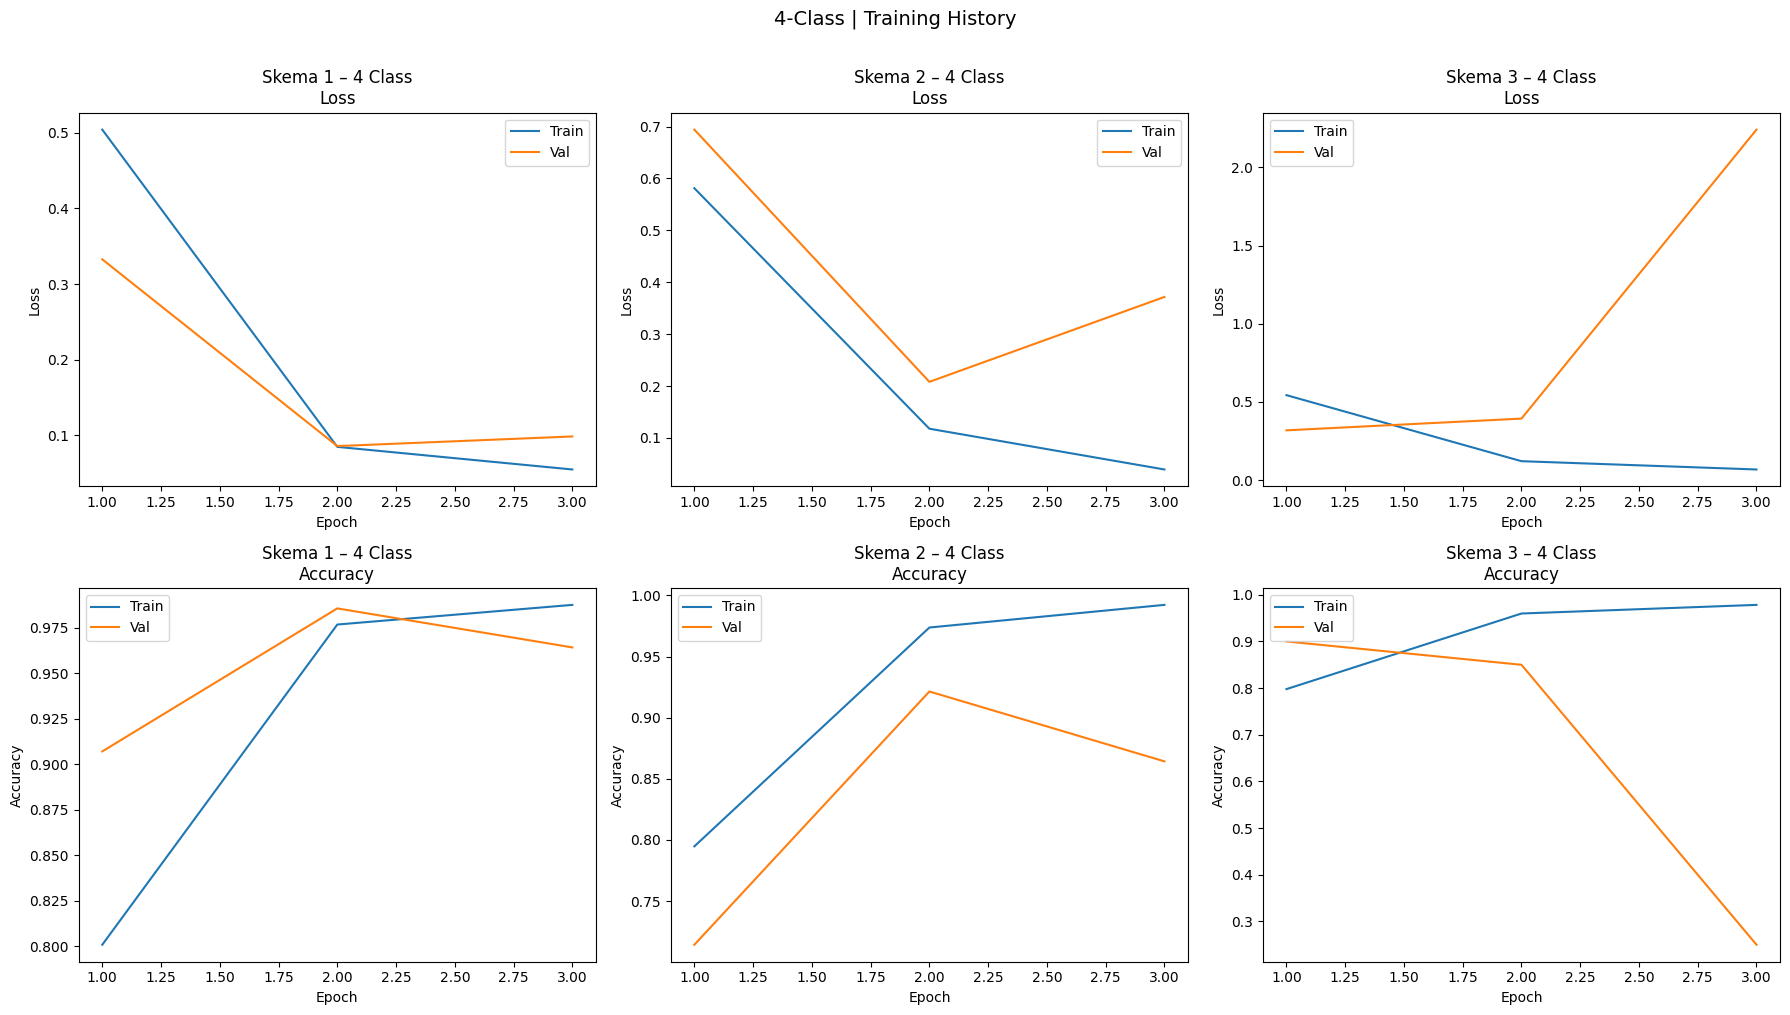

In [26]:
from utils.modeling import plot_training_history

plot_training_history(
    histories={
        "Skema 1 â€“ 4 Class": history_s1_4c,
        "Skema 2 â€“ 4 Class": history_s2_4c,
        "Skema 3 â€“ 4 Class": history_s3_4c,
    },
    title_prefix="4-Class | "
)

### 6.2 Training History â€“ Task 2-Class

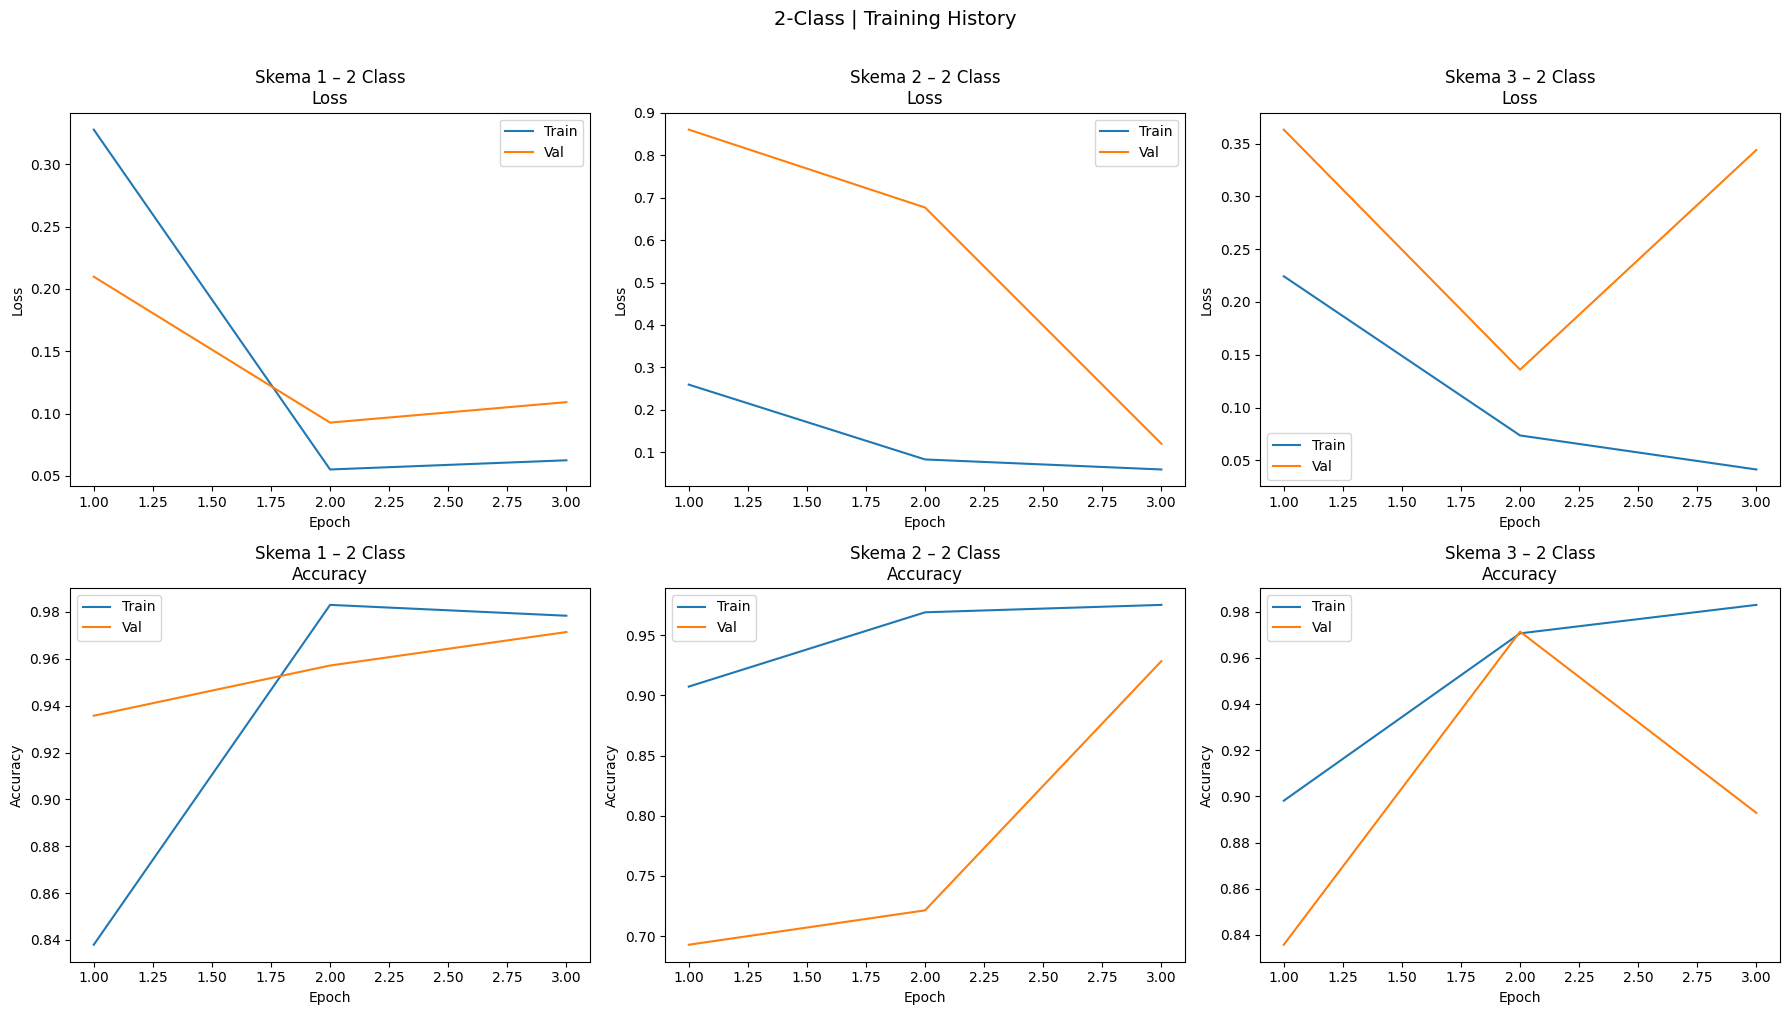

In [27]:
plot_training_history(
    histories={
        "Skema 1 â€“ 2 Class": history_s1_2c,
        "Skema 2 â€“ 2 Class": history_s2_2c,
        "Skema 3 â€“ 2 Class": history_s3_2c,
    },
    title_prefix="2-Class | "
)

### 6.3 Confusion Matrix â€“ Task 4-Class

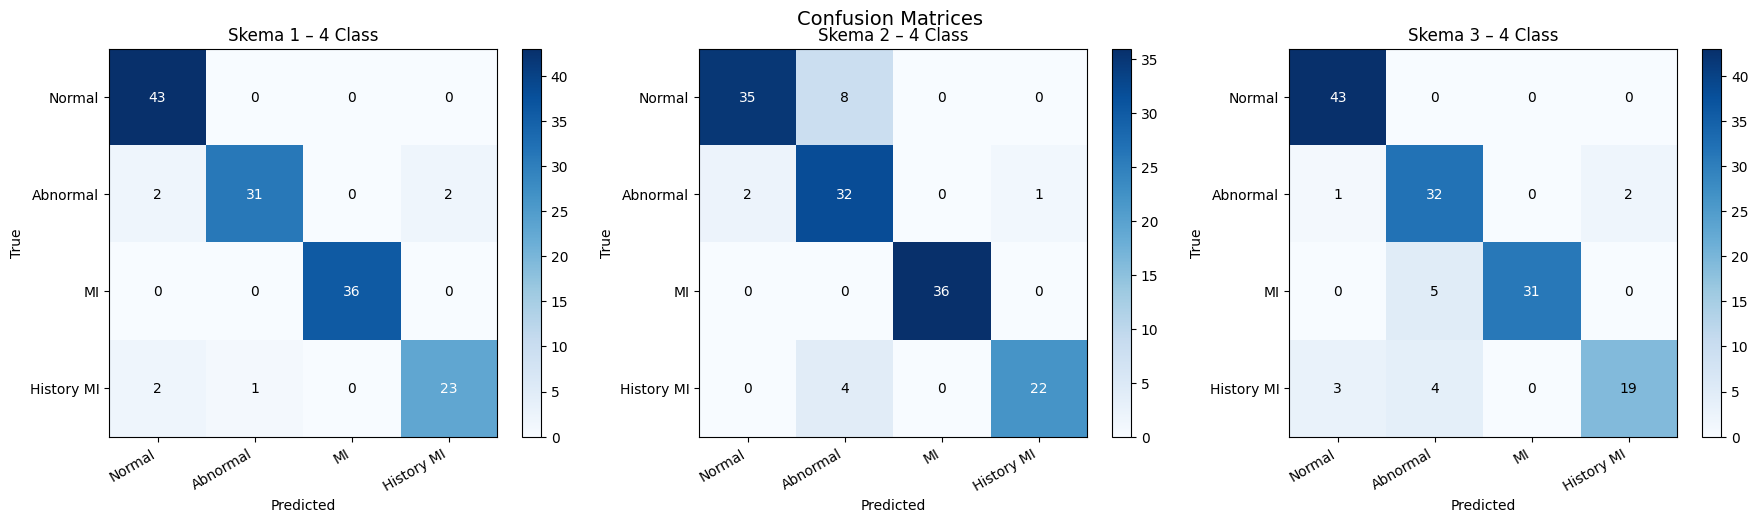

In [28]:
from utils.modeling import plot_confusion_matrices

plot_confusion_matrices(
    results={
        "Skema 1 â€“ 4 Class": result_s1_4c,
        "Skema 2 â€“ 4 Class": result_s2_4c,
        "Skema 3 â€“ 4 Class": result_s3_4c,
    },
    class_names=CLASS_NAMES_4
)

### 6.4 Confusion Matrix â€“ Task 2-Class

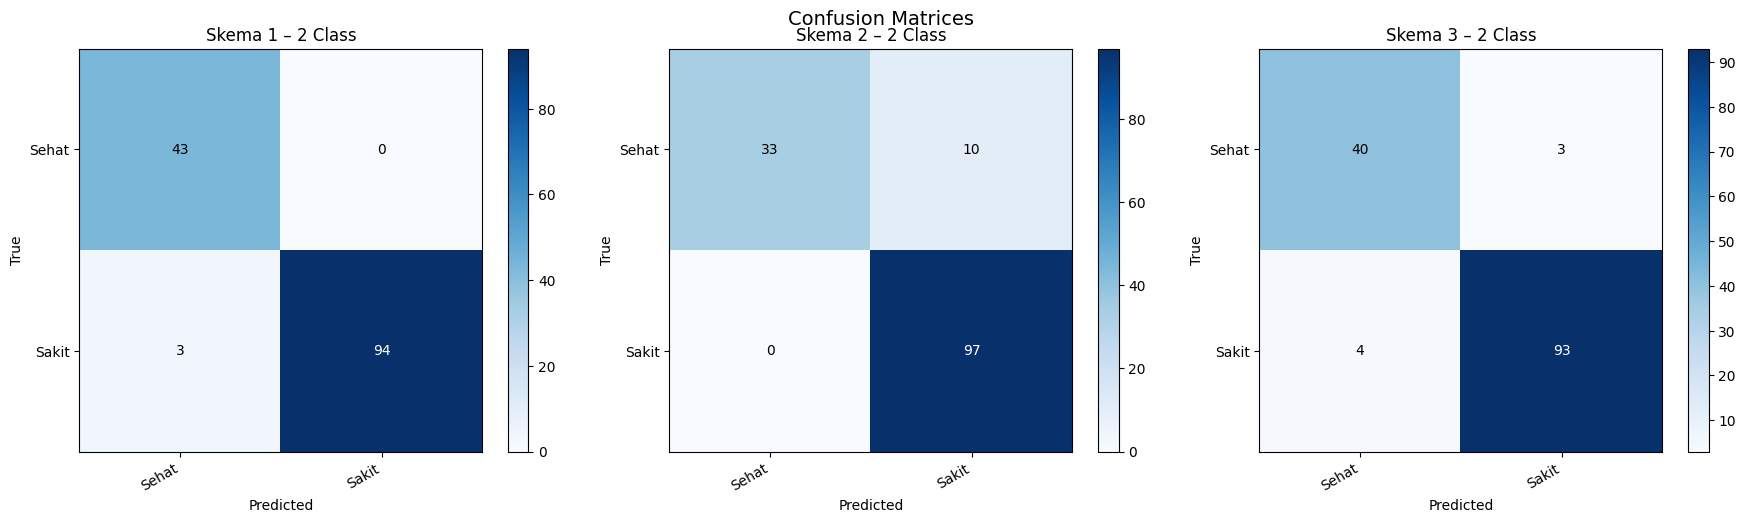

In [29]:
plot_confusion_matrices(
    results={
        "Skema 1 â€“ 2 Class": result_s1_2c,
        "Skema 2 â€“ 2 Class": result_s2_2c,
        "Skema 3 â€“ 2 Class": result_s3_2c,
    },
    class_names=CLASS_NAMES_2
)

### 6.5 Perbandingan Akhir â€“ Accuracy & Macro F1 Semua Skema

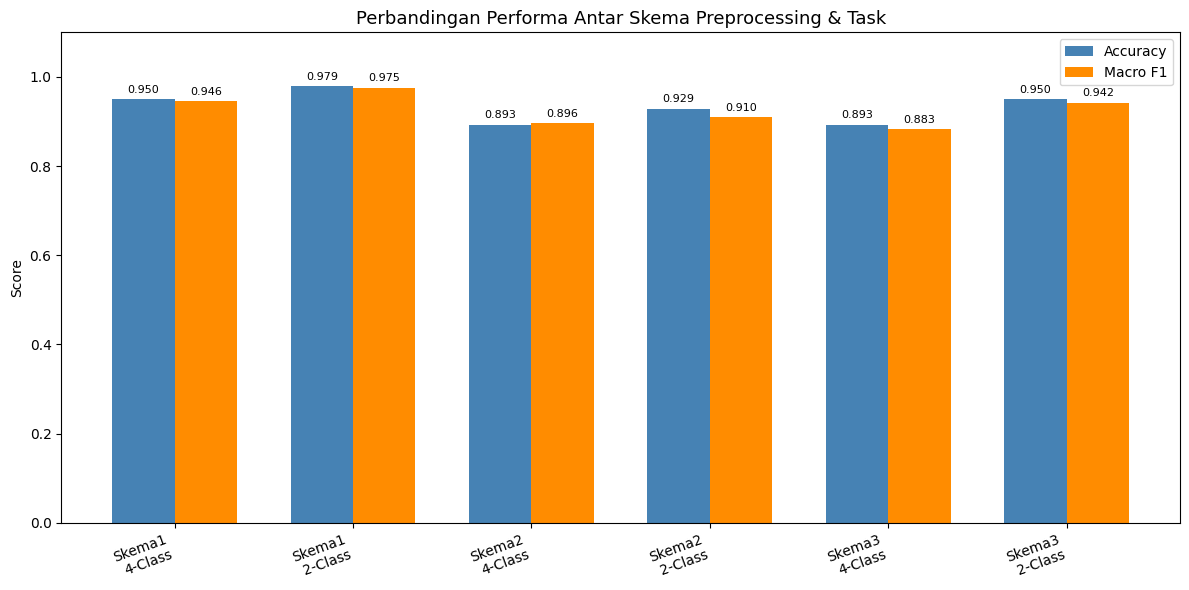

In [30]:
from utils.modeling import plot_scheme_comparison

all_results = {
    "Skema1\n4-Class": result_s1_4c,
    "Skema1\n2-Class": result_s1_2c,
    "Skema2\n4-Class": result_s2_4c,
    "Skema2\n2-Class": result_s2_2c,
    "Skema3\n4-Class": result_s3_4c,
    "Skema3\n2-Class": result_s3_2c,
}

plot_scheme_comparison(all_results)

### 6.6 Sample Predictions â€“ Skema Terbaik

Visualisasi prediksi model pada sampel acak dari dataset test. Ganti variabel `best_model` dan `best_dataset` sesuai skema dengan performa terbaik dari grafik di atas.

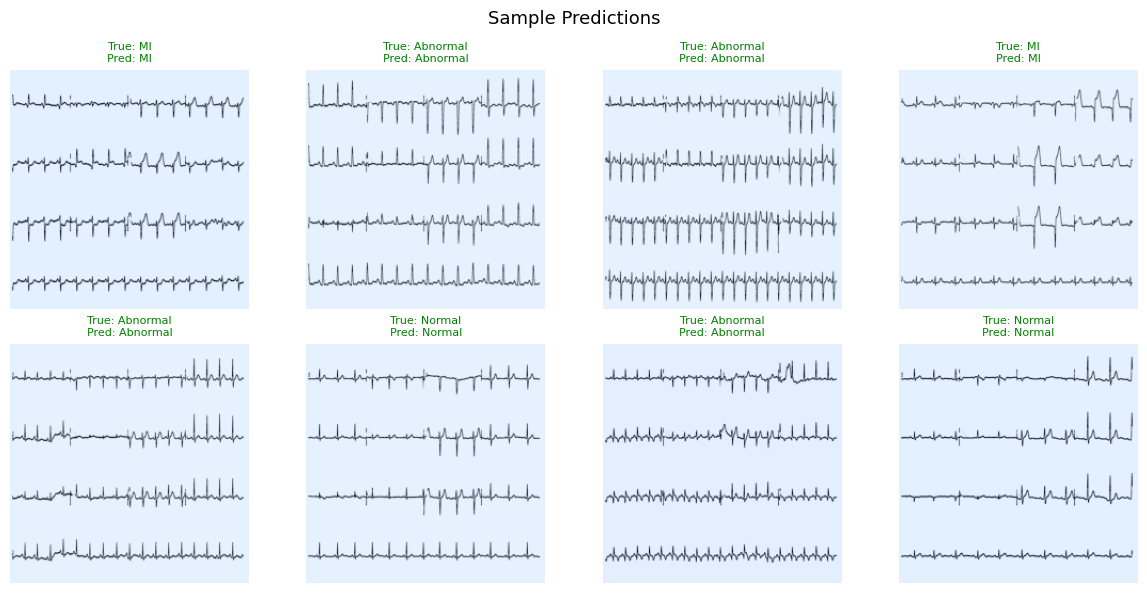

In [31]:
from utils.modeling import plot_sample_predictions

# Ganti model dan dataset sesuai hasil terbaik yang diperoleh
best_model   = model_s1_4c
best_dataset = dataset_s1_4c
best_classes = CLASS_NAMES_4

plot_sample_predictions(
    model=best_model,
    dataset=best_dataset,
    class_names=best_classes,
    device=DEVICE,
    num_samples=8
)